# SentinelIQ — 03 Autoencoder
Reconstruction-based anomaly detection on system metrics using PyTorch.

In [1]:
!git clone https://github.com/hasan-rajab/SentinelIQ.git 2>/dev/null || echo "Already cloned"
import sys
sys.path.append('/kaggle/working/SentinelIQ')
%cd /kaggle/working/SentinelIQ
!pip install pyyaml torch scikit-learn -q


/kaggle/working/SentinelIQ
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have n

In [2]:
!python data/simulated/pipeline.py --duration 120 --anomaly-rate 0.08



  SentinelIQ — Generating Training Data
  Duration: 120s | Anomaly rate: 8%

[log_simulator] Generated 1199 records.
[LOGS   ] ✅ 1199 records | 96 anomalies (8.0%) → data/simulated/logs.jsonl
[network_simulator] Generated 2394 records.
[NETWORK] ✅ 2394 records | 176 anomalies (7.4%) → data/simulated/network.jsonl
[metric_simulator] Generated 1205 records.
[METRICS] ✅ 1205 records | 75 anomalies (6.2%) → data/simulated/metrics.jsonl

  Dataset Summary

  LOGS
    Total records : 1,199
    Anomalies     : 96
    Anomaly types : {'brute_force': 20, 'auth_failure': 17, 'invalid_user': 16, 'privilege_escalation': 13, 'unauthorized_access': 11, 'sqli': 9, 'path_traversal': 8, 'web_shell': 2}

  NETWORK
    Total records : 2,394
    Anomalies     : 176
    Anomaly types : {'c2_beacon': 41, 'dns_tunneling': 37, 'data_exfiltration': 34, 'port_scan': 33, 'lateral_movement': 31}

  METRICS
    Total records : 1,205
    Anomalies     : 75
    Anomaly types : {'cpu_spike': 20, 'network_exfiltratio

In [3]:
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import torch

from ml.models.autoencoder import SentinelAutoencoder

sns.set_theme(style="darkgrid")
print(f"GPU available: {torch.cuda.is_available()}")

with open('configs/model_config.yaml') as f:
    cfg = yaml.safe_load(f)

def load_jsonl(path):
    return pd.DataFrame([json.loads(l) for l in open(path)])


GPU available: True


## Load & Split Data

In [4]:
metrics_df = load_jsonl('data/simulated/metrics.jsonl')
feature_cols = cfg['isolation_forest']['features']
ae_cfg = {**cfg['autoencoder'], 'input_dim': len(feature_cols)}

y = metrics_df['is_anomaly'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    metrics_df, y, test_size=0.2, random_state=42, stratify=y)

X_val, X_test_final, y_val, y_test_final = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

X_train_normal = X_train[y_train == 0]
print(f"Train (normal only): {len(X_train_normal)}")
print(f"Val  : {len(X_val)} | Test: {len(X_test_final)}")


Train (normal only): 904
Val  : 120 | Test: 121


## Train Autoencoder

In [5]:
ae = SentinelAutoencoder(config=ae_cfg, feature_cols=feature_cols)
ae.fit(X_train_normal, val_df=X_val)


[Autoencoder] Training on 904 samples | device=cuda | epochs=50
  Epoch   1/50 | loss=0.95886
  Epoch  10/50 | loss=0.25870
  Epoch  20/50 | loss=0.19487
  Epoch  30/50 | loss=0.18399
  Epoch  40/50 | loss=0.15284
  Epoch  50/50 | loss=0.15143
[Autoencoder] Fitted | threshold (p95)=0.11309


## Evaluate

In [6]:
results = ae.evaluate(X_test_final, y_test_final)



[Autoencoder] Evaluation Results:
  roc_auc             : 1.0
  avg_precision       : 1.0
  precision           : 0.7273
  recall              : 1.0
  f1                  : 0.8421
  accuracy            : 0.9752
  threshold           : 0.113088
  n_samples           : 121
  n_anomalies_true    : 8
  n_anomalies_pred    : 11


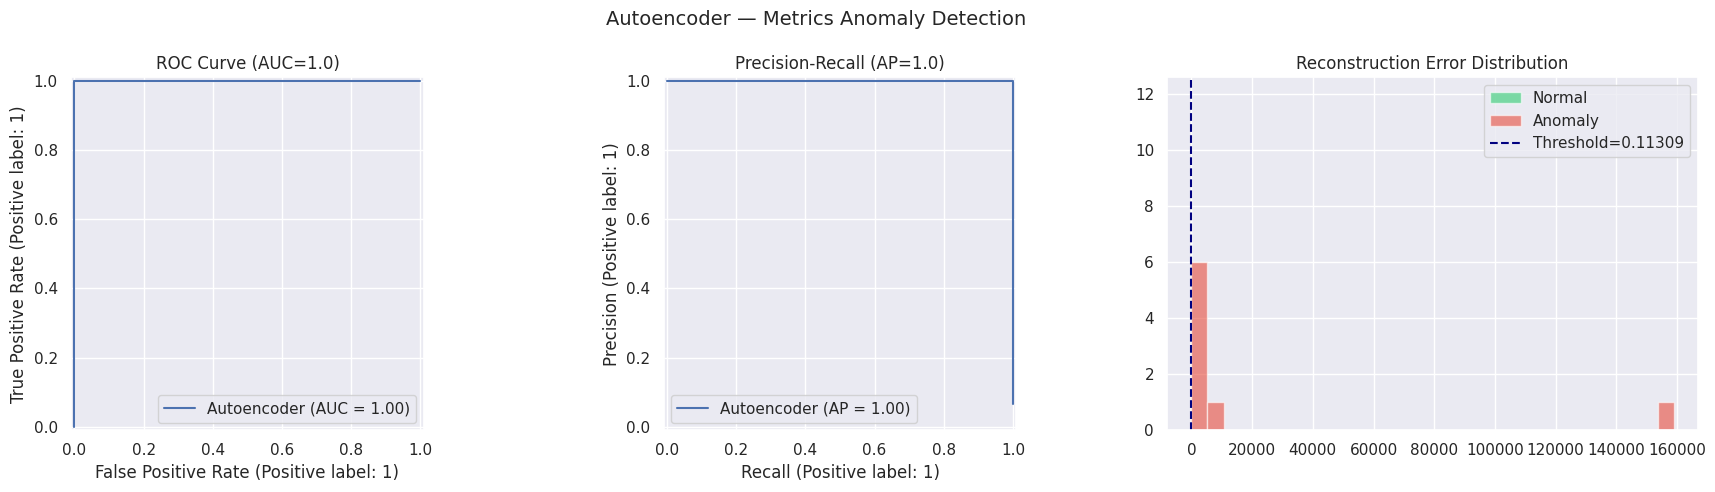

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scores = ae.score(X_test_final)
RocCurveDisplay.from_predictions(y_test_final, scores, ax=axes[0], name='Autoencoder')
axes[0].set_title(f"ROC Curve (AUC={results['roc_auc']})")

PrecisionRecallDisplay.from_predictions(y_test_final, scores, ax=axes[1], name='Autoencoder')
axes[1].set_title(f"Precision-Recall (AP={results['avg_precision']})")

axes[2].hist(scores[y_test_final==0], bins=30, alpha=0.6, color='#2ecc71', label='Normal')
axes[2].hist(scores[y_test_final==1], bins=30, alpha=0.6, color='#e74c3c', label='Anomaly')
axes[2].axvline(ae.threshold, color='navy', linestyle='--', label=f'Threshold={ae.threshold:.5f}')
axes[2].set_title('Reconstruction Error Distribution')
axes[2].legend()

plt.suptitle('Autoencoder — Metrics Anomaly Detection', fontsize=14)
plt.tight_layout()
plt.show()


## Latent Space Visualization

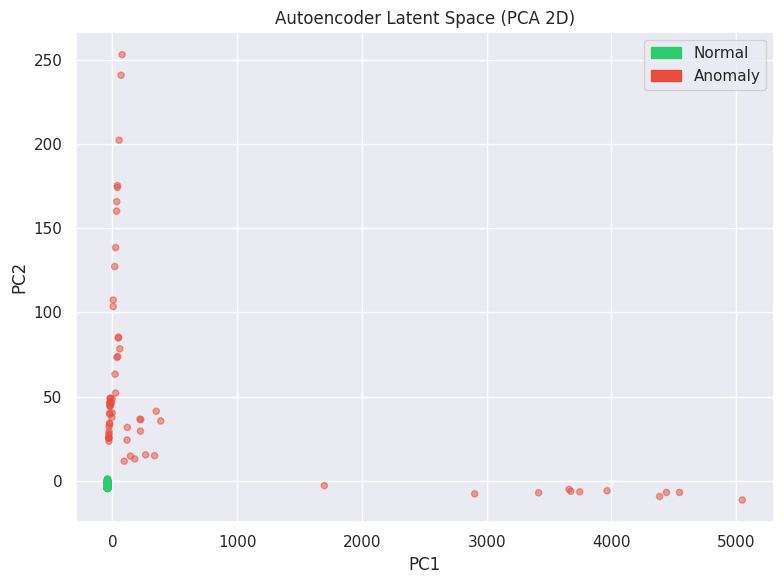

In [8]:
import torch
from sklearn.decomposition import PCA

ae.net.eval()
X_scaled = ae.scaler.transform(metrics_df[feature_cols].fillna(0).values)
X_tensor = torch.FloatTensor(X_scaled).to(ae.device)

with torch.no_grad():
    latent = ae.net.encode(X_tensor).cpu().numpy()

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent)

plt.figure(figsize=(8, 6))
colors = ['#e74c3c' if a else '#2ecc71' for a in metrics_df['is_anomaly']]
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=colors, alpha=0.5, s=20)
plt.title('Autoencoder Latent Space (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#2ecc71', label='Normal'), Patch(color='#e74c3c', label='Anomaly')])
plt.tight_layout()
plt.show()


## Save Model

In [9]:
import os
os.makedirs('ml/saved_models', exist_ok=True)
ae.save('ml/saved_models', name='autoencoder_metrics')
print("Autoencoder saved.")


[Autoencoder] Saved to ml/saved_models/autoencoder_metrics_*
Autoencoder saved.
